In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from scipy.interpolate import RegularGridInterpolator


sys.path.append(str(Path.cwd().resolve().parent.parent))
from rsimpy.cmg.sr3reader import Sr3Reader

In [2]:
file_path = Path('../../SimModels/Unisim_iv_2024/dat_bo/base_case_bo.sr3')
sr3 = Sr3Reader(file_path)
n_krel = sr3.krel.get_number_of_tables()
print(f'Number of krel tables: {n_krel}')

Number of krel tables: 4


In [3]:
kr_table = sr3.krel.get(1)
print(kr_table)

<xarray.SimData> Size: 4kB
Dimensions:     (sl: 22, sw: 24)
Coordinates:
  * sl          (sl) float64 176B 0.58 0.6 0.62 0.64 0.66 ... 0.94 0.96 0.98 1.0
  * sw          (sw) float64 192B 0.18 0.2 0.22 0.24 0.26 ... 0.56 0.58 0.6 1.0
Data variables: (12/20)
    krg         (sl) float64 176B 0.2 0.1905 0.181 0.1714 ... 0.019 0.0095 0.0
    krog        (sl) float64 176B 0.0 0.0 0.0 0.0001 ... 0.1675 0.2057 0.25
    pcgd        (sl) float64 176B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    pcgi        (sl) float64 176B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    sld_g       (sl) float64 176B 0.0 0.04762 0.09524 ... 0.9048 0.9524 1.0
    sld_o       (sl) float64 176B -0.1053 -0.05263 0.0 ... 0.8947 0.9474 1.0
    ...          ...
    swd_w       (sw) float64 192B 0.0 0.02439 0.04878 ... 0.4878 0.5122 1.0
    swd_o       (sw) float64 192B 0.0 0.05 0.1 0.15 0.2 ... 0.95 1.0 1.05 2.05
    swd_w_3pta  (sw) float64 192B 0.0 0.05 0.1 0.15 0.2 ... 0.95 1.0 1.05 2.05
    swd_o_3pta  (sw) fl

In [4]:
for k,v in kr_table.attrs.items():
    try:
        v = f'{float(v):.5f}'
    except ValueError:
        v = str(v)
    print(f' {k:10s}: {v}')

 element_type: krel
 swcon     : 0.18000
 swcrit    : 0.18000
 sorw      : 0.42000
 soirw     : 0.00000
 slcon     : 0.58000
 slrg      : 0.62000
 sgcrit    : 0.00000
 sgcon     : 0.00000
 sorg      : 0.44000
 soirg     : 0.40000
 sgir      : 0.00000
 krw_max   : 1.00000
 krg_max   : 0.20000
 kro_max   : 0.25000
 krw_sorw  : 0.27747
 krg_sorg  : 0.18100
 sw_w_3pt  : 0.58000
 krw_3pt   : 1.00000
 sw_o_3pt  : 0.18000
 krow_3pt  : 0.00000
 sl_g_3pt  : 0.62000
 krg_3pt   : 1.00000
 sl_o_3pt  : 0.62000
 krog_3pt  : 0.00000


In [5]:
def interp_extrap(x, y, new_x, extrap=True):
    """
    Perform linear interpolation and extrapolation.

    Extrapolates using the two lowest or two largest points if new_x is outside x range.

    Parameters
    ----------
    x : array_like
        Known x-coordinates.
    y : array_like
        Known y-coordinates corresponding to x.
    new_x : array_like
        New x-coordinates where interpolation/extrapolation is desired.
    extrap : bool, optional
        If True, extrapolate outside the range of x. Default is True.

    Returns
    -------
    y_interp : ndarray
        Interpolated or extrapolated y-coordinates corresponding to new_x.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    new_x = np.asarray(new_x)
    y_interp = np.interp(new_x, x, y)
    if not extrap:
        return y_interp

    below = new_x < x[0]
    if np.any(below):
        slope = (y[1] - y[0]) / (x[1] - x[0])
        y_interp[below] = y[0] + slope * (new_x[below] - x[0])

    above = new_x > x[-1]
    if np.any(above):
        slope = (y[-1] - y[-2]) / (x[-1] - x[-2])
        y_interp[above] = y[-1] + slope * (new_x[above] - x[-1])
    return y_interp

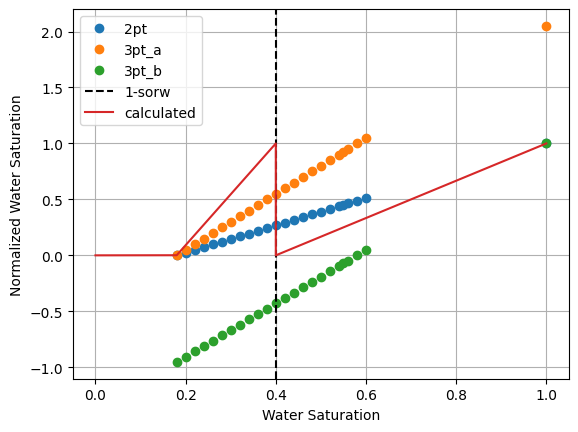

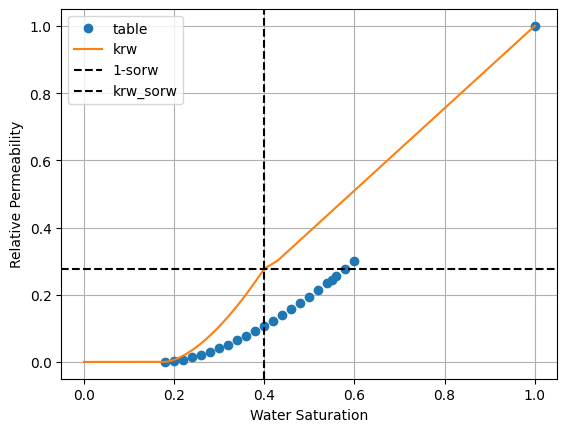

In [39]:
def get_swd_w(sw, three_pt_scl=False, swcrit=None, sorw=None, soirw=None, clip=True):
    """
    Get the normalized water saturation, for Krw calculation.

    Parameters
    ----------
    sw : float or np.ndarray
        Water saturation.
    three_pt_scl : bool, optional
        If True, uses the three-point scaling method for the relative permeability.
    swcrit : float, optional
        Critical water saturation. If None, it is taken from the kr_table.
    sorw : float, optional
        Residual oil saturation. If None, it is taken from the kr_table.
    soirw : float, optional
        Residual water saturation. If None, it is taken from the kr_table.
    clip : bool, optional
        If True, clips the normalizaed input to the range [0, 1]. Default is True
    """
    swcrit = swcrit if swcrit is not None else kr_table.attrs['swcrit']
    sorw = sorw if sorw is not None else kr_table.attrs['sorw']
    soirw = soirw if soirw is not None else kr_table.attrs['soirw']
    sw = np.asarray(sw, dtype=float)

    use_3pt_scl = three_pt_scl and \
        kr_table.attrs['krw_3pt'] and \
        (1 - sorw - swcrit > 0.01) and \
        (sorw - soirw > 0.01)

    if use_3pt_scl:
        swd = np.where(sw <= 1-sorw,
              (sw - swcrit) / (1 - sorw - swcrit),
              (sw - 1 + sorw) / (sorw - soirw)
        )
    else:
        swd = (sw - swcrit) / (1 - soirw - swcrit)

    if clip:
        swd = np.clip(swd, 0, 1)
    else:
        if swd.min() < 0 or swd.max() > 1:
            msg = f'Normalized water saturation is out of bounds [0, 1]: {swd.min()} - {swd.max()}'
            raise ValueError(msg)

    return swd


def get_krw(kr_table, sw, three_pt_scl=False, swcrit=None, sorw=None, soirw=None, clip=True):
    """
    Get the water relative permeability for a given saturation.

    Parameters
    ----------
    kr_table : xarray.Dataset
        The relative permeability table.
    sw : float or np.ndarray
        Water saturation.
    three_pt_scl : bool, optional
        If True, uses the three-point scaling method for the relative permeability.
    swcrit : float, optional
        Critical water saturation. If None, it is taken from the kr_table.
    sorw : float, optional
        Residual oil saturation. If None, it is taken from the kr_table.
    soirw : float, optional
        Residual water saturation. If None, it is taken from the kr_table.
    clip : bool, optional
        If True, clips the normalizaed input to the range [0, 1]. Default is True
    """
    swcrit = swcrit if swcrit is not None else kr_table.attrs['swcrit']
    sorw = sorw if sorw is not None else kr_table.attrs['sorw']
    soirw = soirw if soirw is not None else kr_table.attrs['soirw']
    sw = np.asarray(sw, dtype=float)

    use_3pt_scl = three_pt_scl and \
        kr_table.attrs['krw_3pt'] and \
        (1 - sorw - swcrit > 0.01) and \
        (sorw - soirw > 0.01)

    swd = get_swd_w(sw, three_pt_scl=use_3pt_scl, swcrit=swcrit, sorw=sorw, soirw=soirw, clip=clip)

    krw_table = kr_table['krw'].values
    if use_3pt_scl:
        swd_a = kr_table['swd_w_3pta'].values
        swd_b = kr_table['swd_w_3ptb'].values

        krw = np.where(sw <= 1-sorw,
                       interp_extrap(swd_a, krw_table, swd, extrap=True),
                       interp_extrap(swd_b, krw_table, swd, extrap=True)
        )

    else:
        swd_w = kr_table['swd_w'].values
        krw = interp_extrap(swd_w, krw_table, swd, extrap=True)
    return krw

sorw=0.60
sw = np.linspace(0, 1, 100000)
krw = get_krw(kr_table, sw, three_pt_scl=True, clip=True, swcrit=None, sorw=sorw, soirw=None)
swd = get_swd_w(sw, three_pt_scl=True, clip=True, swcrit=None, sorw=sorw, soirw=None)

sw_table = kr_table['sw'].values

_, ax = plt.subplots()
# ax.plot(sw_table, krw_table, label='krw', marker='o', linestyle='None')
ax.plot(sw_table, kr_table['swd_w'].values, label='2pt', marker='o', linestyle='None')
ax.plot(sw_table, kr_table['swd_w_3pta'].values, label='3pt_a', marker='o', linestyle='None')
ax.plot(sw_table, kr_table['swd_w_3ptb'].values, label='3pt_b', marker='o', linestyle='None')
ax.axvline(1-sorw, color='k', linestyle='--', label='1-sorw')
ax.plot(sw, swd, label='calculated')
ax.set_xlabel('Water Saturation')
ax.set_ylabel('Normalized Water Saturation')
ax.legend()
ax.grid()
plt.show()
plt.close()


_, ax = plt.subplots()
ax.plot(sw_table, kr_table['krw'], label='table', marker='o', linestyle='None')
ax.plot(sw, krw, label='krw')
ax.axvline(1-sorw, color='k', linestyle='--', label='1-sorw')
ax.axhline(kr_table.attrs['krw_sorw'], color='k', linestyle='--', label='krw_sorw')
ax.set_xlabel('Water Saturation')
ax.set_ylabel('Relative Permeability')
ax.legend()
ax.grid()
plt.show()
plt.close()

In [35]:
get_krw(kr_table, 1-sorw, three_pt_scl=True, clip=True, swcrit=None, sorw=sorw, soirw=None)

array(0.27747)

In [37]:
kr_table.attrs['krw_sorw']

0.27747000000000005

## Sat

In [ ]:
def interp_extrap(x, y, new_x, extrap=True):
    """
    Perform linear interpolation and extrapolation.

    Extrapolates using the two lowest or two largest points if new_x is outside x range.

    Parameters
    ----------
    x : array_like
        Known x-coordinates.
    y : array_like
        Known y-coordinates corresponding to x.
    new_x : array_like
        New x-coordinates where interpolation/extrapolation is desired.
    extrap : bool, optional
        If True, extrapolate outside the range of x. Default is True.

    Returns
    -------
    y_interp : ndarray
        Interpolated or extrapolated y-coordinates corresponding to new_x.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    new_x = np.asarray(new_x)
    y_interp = np.interp(new_x, x, y)
    if not extrap:
        return y_interp

    below = new_x < x[0]
    if np.any(below):
        slope = (y[1] - y[0]) / (x[1] - x[0])
        y_interp[below] = y[0] + slope * (new_x[below] - x[0])

    above = new_x > x[-1]
    if np.any(above):
        slope = (y[-1] - y[-2]) / (x[-1] - x[-2])
        y_interp[above] = y[-1] + slope * (new_x[above] - x[-1])
    return y_interp

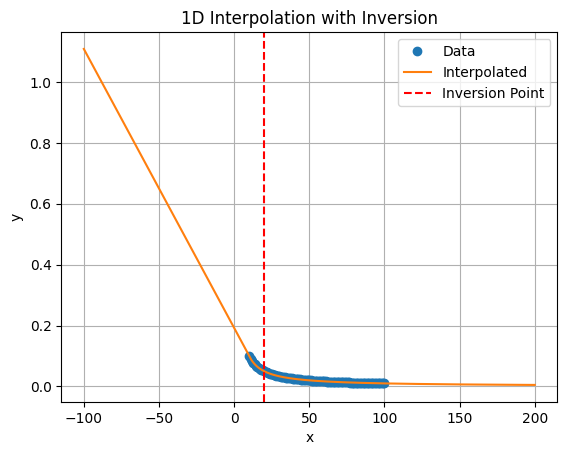

In [ ]:
def alt_interp1d(x, y, x_new, x_inversion=-np.inf, inverse_smaller=True, extrap=True):
    """
    1D interpolation part linear, part linear to the inverse.

    Parameters
    ----------
    x : array_like
        The x-coordinates of the data points.
    y : array_like
        The y-coordinates of the data points.
    x_new : array_like
        The x-coordinates where the interpolation is evaluated.
    x_inversion : float, optional
        The x-coordinate where the interpolation switches from linear to inverse.
        Default is -np.inf, meaning no switch.
    inverse_smaller : bool, optional
        If True, the inverse interpolation is applied for x values smaller than x_inversion.
        If False, it is applied for x values larger than x_inversion.
        Default is True.
    extrap : bool, optional
        If True, extrapolation is performed for x values outside the range of x.
        If False, values outside the range will not be extrapolated.
        Default is True.
    Returns
    -------
    y_interp : array_like
        The interpolated y-coordinates corresponding to the input x values.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    if inverse_smaller:
        mask = x_new < x_inversion
    else:
        mask = x_new > x_inversion

    y_interp = np.zeros_like(x_new)
    y_interp[mask] = 1/interp_extrap(x, 1/(y+1E-20), x_new[mask], extrap=extrap)
    y_interp[~mask] = interp_extrap(x, y, x_new[~mask], extrap=extrap)

    return y_interp

x = np.linspace(10, 100, 100)
y = 1/x
x_new = np.linspace(-100, 200, 5000)
y_interp = alt_interp1d(x, y, x_new, x_inversion=20, inverse_smaller=False, extrap=True)
plt.plot(x, y, 'o', label='Data')
plt.plot(x_new, y_interp, label='Interpolated')
plt.axvline(20, color='red', linestyle='--', label='Inversion Point')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('1D Interpolation with Inversion')
plt.grid()
plt.show()

In [ ]:
pvt['sat'].keys()

dict_keys(['PRES', 'RS', 'BO', 'EG', 'UO', 'UG'])

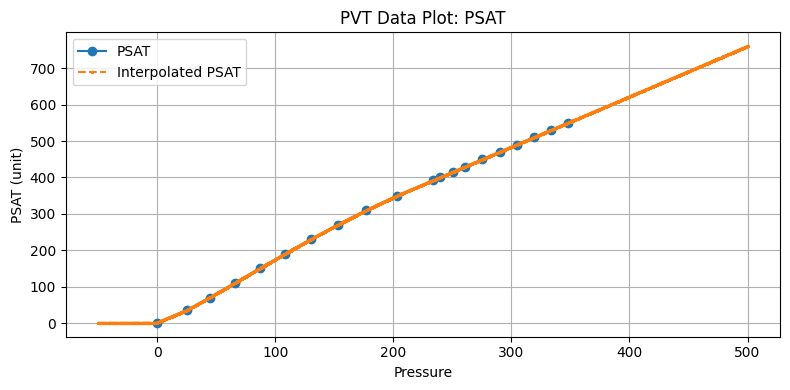

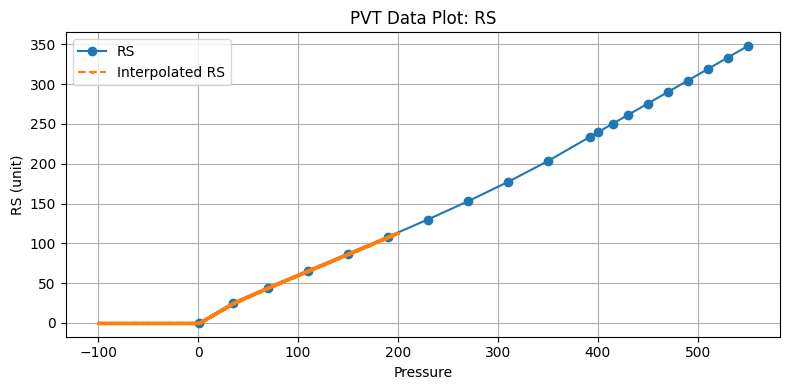

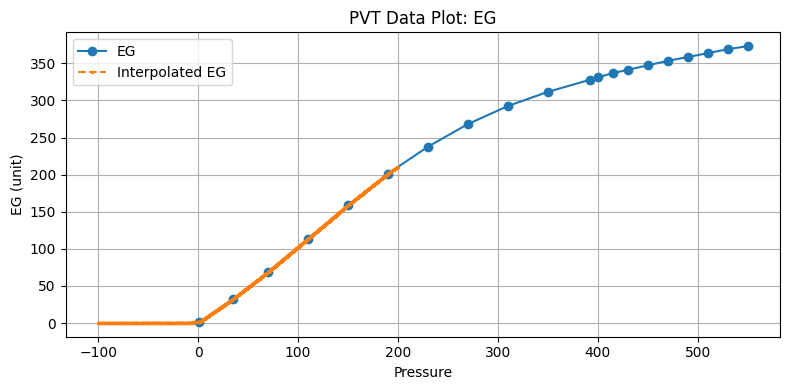

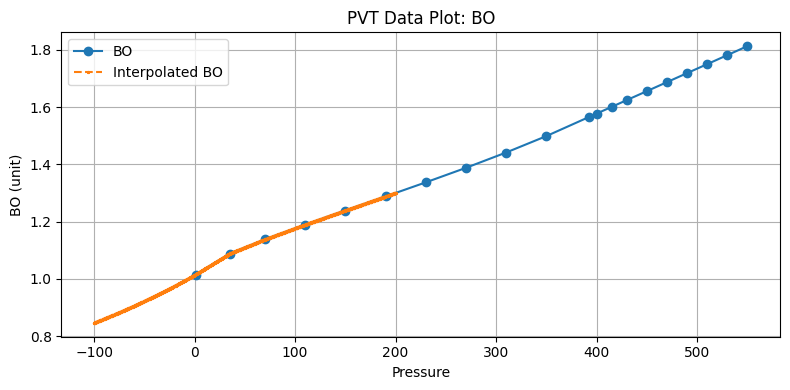

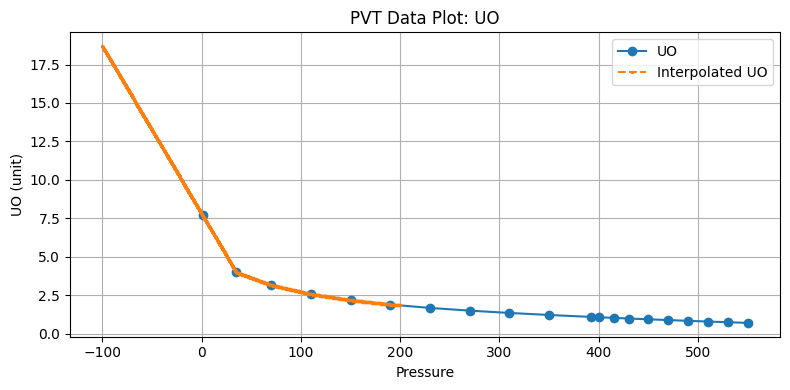

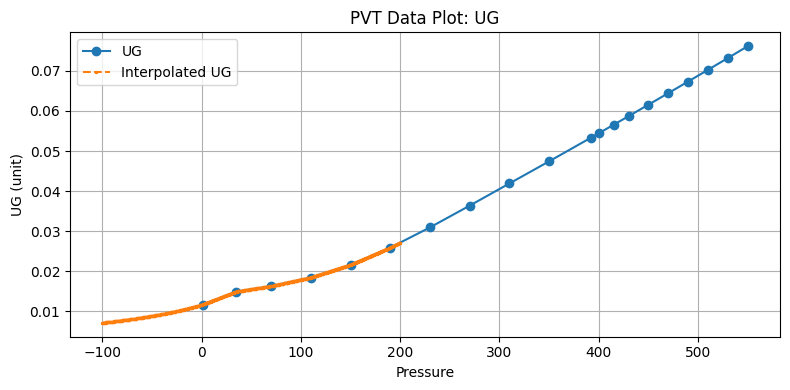

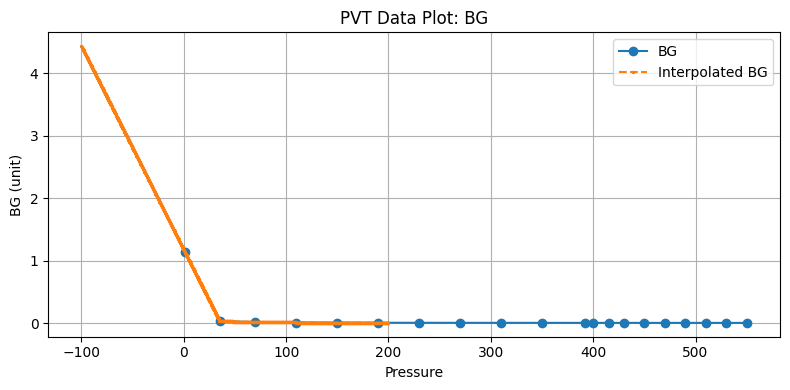

In [ ]:
for col in ['PSAT', 'RS', 'EG', 'BO', 'UO', 'UG','BG']:
    plt.figure(figsize=(8, 4))

    p_ = np.linspace(-100, 200, 1000)
    if col == 'BG':
        v_ = 1/alt_interp1d(
            x=pvt['sat']['PRES'],
            y=pvt['sat']['EG'],
            x_new=p_,
            x_inversion=pvt['sat']['PRES'][-1],
            inverse_smaller=(col!='UO'),
            extrap=True
            )
        plt.plot(pvt['sat']['PRES'], 1/pvt['sat']['EG'], label=col, marker='o')
    elif col == 'PSAT':
        p_ = np.linspace(-50, 500, 1000)
        v_ = alt_interp1d(
            x=pvt['sat']['RS'],
            y=pvt['sat']['PRES'],
            x_new=p_,
            x_inversion=pvt['sat']['RS'][0],
            inverse_smaller=True,
            extrap=True
            )
        plt.plot(pvt['sat']['RS'], pvt['sat']['PRES'], label=col, marker='o')
    else:
        i = -1 if col == 'UO' else 0
        v_ = alt_interp1d(
            x=pvt['sat']['PRES'],
            y=pvt['sat'][col],
            x_new=p_,
            x_inversion=pvt['sat']['PRES'][i],
            inverse_smaller=(col!='UO'),
            extrap=True
            )
        plt.plot(pvt['sat']['PRES'], pvt['sat'][col], label=col, marker='o')
    # plt.yscale('log')

    plt.plot(p_, v_, label=f'Interpolated {col}', linestyle='--', marker='*', markersize=2)
    plt.title(f'PVT Data Plot: {col}')
    plt.xlabel('Pressure')
    plt.ylabel(f'{col} (unit)')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

## Sub-sat

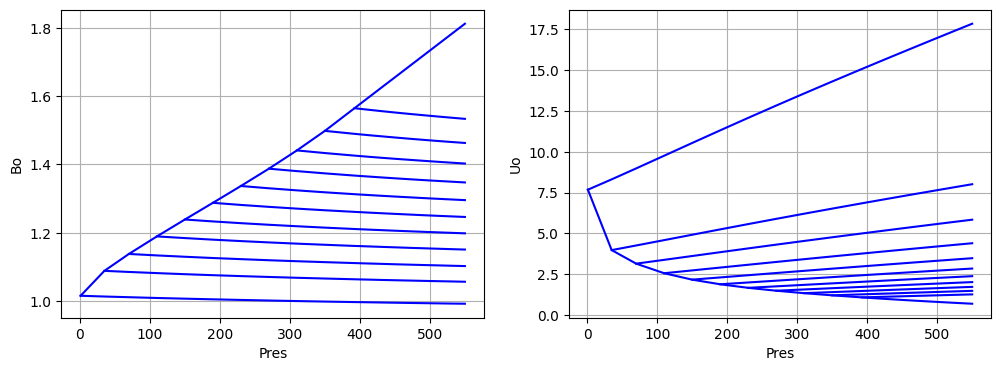

In [ ]:
def bo_plot(p='b', ax=None):
    if ax is None:
        _, ax = plt.subplots(1,1)
    ax.plot(pvt['sat']['PRES'], pvt['sat'][f'{p.upper()}O'], color='b')
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        ax.plot(sub_sat['PRES'], sub_sat['val'], color='b')
    ax.set_xlabel('Pres')
    ax.set_ylabel(f'{p.upper()}o')
    ax.grid()

_, axes = plt.subplots(1,2, figsize=(12,4))
bo_plot('b', ax=axes[0])
bo_plot('u', ax=axes[1])
plt.show()

In [ ]:
def interp_2D(x, y, new_x, interpolator=None, extrap=True):
    """Control extrapolation behavior for 2D interpolation."""
    x_ = []
    for i in range(len(x)):
        x_.append(np.asarray(x[i]))
    y = np.asarray(y)
    extrap = np.asarray(extrap, dtype=bool)
    new_x = np.asarray(new_x).copy()

    if interpolator is None:
        interpolator = RegularGridInterpolator(x_, y, bounds_error=False, fill_value=None)

    for i in range(new_x.shape[1]):
        if not extrap[i]:
            below = new_x[:,i] < x_[i][0]
            if np.any(below):
                new_x[below,i] = x_[i][0]
            above = new_x[:,i] > x_[i][-1]
            if np.any(above):
                new_x[above,i] = x_[i][-1]

    return interpolator(new_x)

# Example usage of interp_2D
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([10, 20, 30])
z = np.array([
    [10, 20, 30, 40, 50, 60],
    [110, 120, 130, 140, 150, 160],
    [210, 220, 230, 240, 250, 260],
    ]).T
new_x = np.array([[1.5, 25], [2, 500], [0,0]])
interpolator = RegularGridInterpolator((x, y), z, bounds_error=False, fill_value=None)
result = interp_2D((x, y), z, new_x, interpolator=interpolator, extrap=[True,False])
print("Interpolated result:", result)
result2 = interp_2D((x, y), z, new_x, extrap=[True,True])
print("Interpolated result:", result2)
result2 = interp_2D((x, y), z, new_x, extrap=[False,True])
print("Interpolated result:", result2)
result2 = interp_2D((x, y), z, new_x, extrap=[False,False])
print("Interpolated result:", result2)

Interpolated result: [165. 220.   0.]
Interpolated result: [ 165. 4920. -100.]
Interpolated result: [ 165. 4920.  -90.]
Interpolated result: [165. 220.  10.]


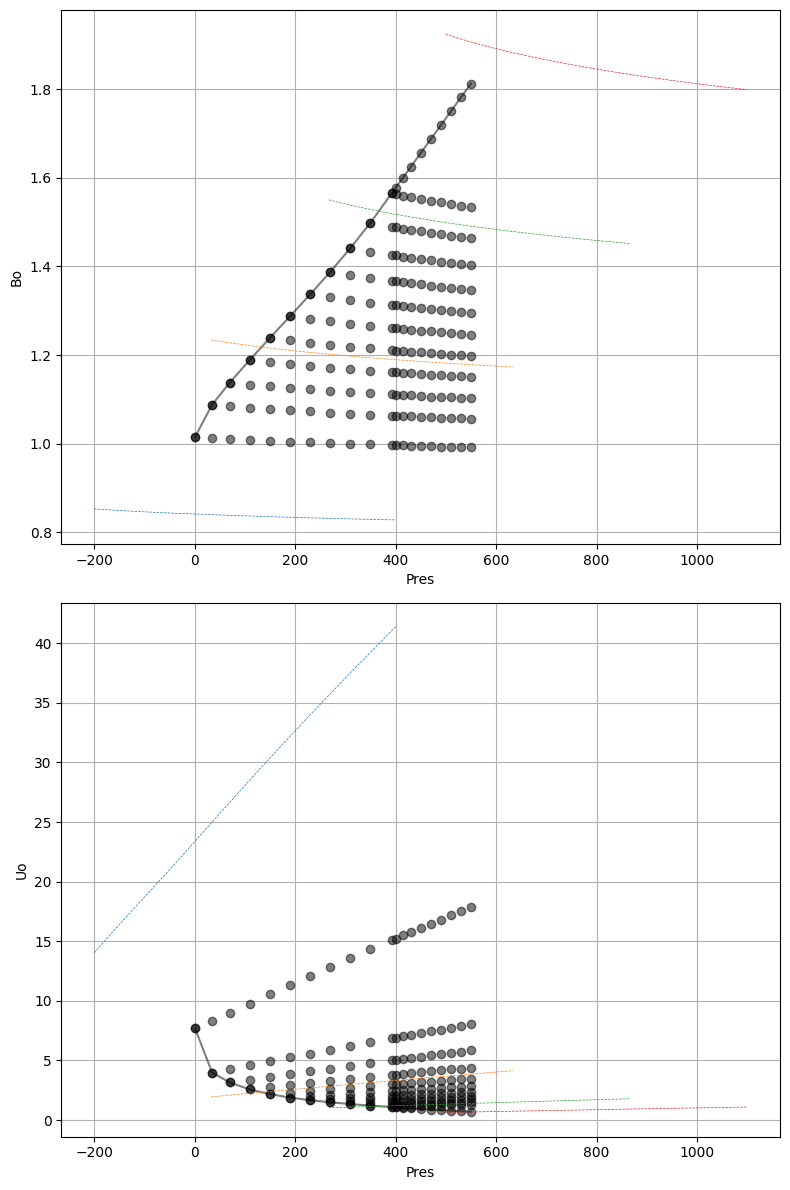

In [ ]:
EPS = 1e-6
psat = {}
vsat = {}
comp = {}
slopes = {}
betas = {}
_, axes = plt.subplots(2,1, figsize=(8, 12))
axes = axes.flatten()
for ii, p in enumerate(['b','u']):
    # _, axes = plt.subplots(2,2, figsize=(18, 12))
    # axes = axes.flatten()

    axes[ii].plot(pvt['sat']['PRES'], pvt['sat'][f'{p.upper()}O'], '-o', color='k', alpha=0.5)
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        axes[ii].plot(sub_sat['PRES'], sub_sat['val'], 'o', color='k', alpha=0.5)
    axes[ii].set_xlabel('Pres')
    axes[ii].set_ylabel(f'{p.upper()}o')

    psat[p] = list()
    vsat[p] = list()
    comp[p] = list()
    slopes[p] = list()
    betas[p] = list()
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        psat[p].append(sub_sat['PRES'][0])
        vsat[p].append(sub_sat['val'][0])

        d_pres = sub_sat['PRES'][1:] - sub_sat['PRES'][:-1]
        d_val = sub_sat['val'][1:] - sub_sat['val'][:-1]
        d = np.stack([
            sub_sat['PRES'][:-1] - sub_sat['PRES'][0],
            d_val/d_pres / sub_sat['val'][:-1]],
            axis=0)
        comp[p].append(d)

        x = d[0, :]
        y = 1 / d[1, :]
        # axes[0].plot(x, y)
        slope, intercept, r_value, p_value, std_err = linregress(x, y)

        # axes[0].plot(x, slope * x + intercept, '--', linewidth=0.5, color='k')
        slopes[p].append([sub_sat['PRES'][0], slope])

        delta_p = sub_sat['PRES'][1:] - sub_sat['PRES'][0]
        beta = slope * delta_p / (np.power(sub_sat['val'][1:]/sub_sat['val'][0], slope) - 1)
        # axes[2].plot(delta_p, beta,'-o')

        betas[p].append([delta_p, beta])

    #Build interpolator
    all_deltas = np.concatenate([x[0] for x in betas[p]])
    # all_deltas = np.concatenate([all_deltas, [-100, 0, 2000]])
    all_deltas = np.unique(all_deltas)
    all_deltas = np.sort(all_deltas)
    # print(f'All deltas: {all_deltas}')
    all_betas = []
    for beta in betas[p]:
        beta_interp = 1/interp_extrap(beta[0], 1/beta[1], all_deltas, extrap=False)
        all_betas.append(beta_interp)
        # axes[2].plot(all_deltas, beta_interp,'--', linewidth=0.5, color='k')
    all_betas = np.array(all_betas)

    beta_interp2d = RegularGridInterpolator((psat[p], all_deltas), 1/all_betas, bounds_error=False, fill_value=None)

    extrap_psat = np.linspace(-100, 600, 4)
    extrap_deltas = np.linspace(-100, 500, 1000)
    if p == 'b':
        vs = interp_extrap(psat[p], np.array(vsat[p]), extrap_psat)
        vs_inv = 1/interp_extrap(psat[p], 1/np.array(vsat[p]), extrap_psat)
        vs[extrap_psat < psat[p][0]] = vs_inv[extrap_psat < psat[p][0]]
    elif p == 'u':
        vs = interp_extrap(psat[p], np.array(vsat[p]), extrap_psat)
        vs_inv = 1/interp_extrap(psat[p], 1/np.array(vsat[p]), extrap_psat)
        vs[extrap_psat > psat[p][-1]] = vs_inv[extrap_psat > psat[p][-1]]
    alpha = interp_extrap([x[0] for x in slopes[p]], [x[1] for x in slopes[p]], extrap_psat, extrap=False)
    for pr, vs, alpha in zip(extrap_psat, vs, alpha):
        beta_interp = 1/interp_2D(
            (psat[p], all_deltas), 1/all_betas,
            new_x=np.stack(([pr]*extrap_deltas.shape[0], extrap_deltas), axis=1),
            interpolator=beta_interp2d,
            extrap=[False, False])

        # beta_interp = 1/beta_interp2d((pr, extrap_deltas))
        s = alpha * extrap_deltas / beta_interp + 1
        s[s < EPS] =  - EPS / extrap_deltas[s < EPS] # avoid negative values inside the power
        new_values = vs * np.power(s, 1/alpha)
        # axes[1].plot(extrap_deltas + pr, 1/beta_interp, linewidth=0.5, linestyle='--')
        axes[ii].plot(extrap_deltas + pr, new_values, linewidth=0.5, linestyle='--')

    # axes[0].set_xlabel('Delta Pressure')
    # axes[0].set_ylabel(f'{p.upper()}o/(d{p.upper()}o/dP)')


    # axes[1].plot(psat[p], 1/all_betas[:,0], '-o', label=f'{p.upper()}o')


    # axes[1].plot([x[0] for x in slopes[p]], [x[1] for x in slopes[p]], '-o', label=f'{p.upper()}o')
    # axes[1].set_xlabel('Pressure')
    # axes[1].set_ylabel(f'Slope of {p.upper()}o/(d{p.upper()}o/dP)')

    # axes[2].set_xlabel('Delta Pressure')
    # axes[2].set_ylabel(f'Beta of {p.upper()}o')
    # axes[2].set_xscale('log')

axes[0].grid()
axes[1].grid()
# axes[2].grid()
# axes[3].grid()

plt.tight_layout()
plt.show()

In [ ]:
interp_extrap([x[0] for x in slopes[p]], [x[1] for x in slopes[p]], extrap_psat, extrap=False)

array([-38.57011906, -20.64785609, -15.21678352, -14.77153625])

In [ ]:
extrap_psat

array([-100.        ,  133.33333333,  366.66666667,  600.        ])

In [ ]:
slopes[p]

[[np.float64(1.03), np.float64(-38.57011905779648)],
 [np.float64(35.0), np.float64(-26.93889222334176)],
 [np.float64(70.0), np.float64(-24.136843257872847)],
 [np.float64(110.0), np.float64(-22.020803647983293)],
 [np.float64(150.0), np.float64(-19.667179270627233)],
 [np.float64(190.0), np.float64(-18.63103219584059)],
 [np.float64(230.0), np.float64(-17.008745896391133)],
 [np.float64(270.0), np.float64(-15.827157078770044)],
 [np.float64(310.0), np.float64(-15.277236773421619)],
 [np.float64(350.0), np.float64(-15.506394067181322)],
 [np.float64(392.29), np.float64(-14.771536254444392)]]

In [ ]:
psat

{'b': [np.float64(1.03),
  np.float64(35.0),
  np.float64(70.0),
  np.float64(110.0),
  np.float64(150.0),
  np.float64(190.0),
  np.float64(230.0),
  np.float64(270.0),
  np.float64(310.0),
  np.float64(350.0),
  np.float64(392.29)]}

In [ ]:
all_deltas

array([  7.71,  22.71,  33.97,  35.  ,  37.71,  40.  ,  42.29,  50.  ,
        57.71,  65.  ,  68.97,  75.  ,  77.71,  80.  ,  82.29,  90.  ,
        97.71, 100.  , 105.  , 108.97, 115.  , 117.71, 120.  , 122.29,
       130.  , 137.71, 140.  , 145.  , 148.97, 155.  , 157.71, 160.  ,
       162.29, 170.  , 180.  , 185.  , 188.97, 195.  , 200.  , 202.29,
       210.  , 220.  , 225.  , 228.97, 235.  , 240.  , 242.29, 250.  ,
       260.  , 265.  , 268.97, 275.  , 280.  , 282.29, 290.  , 300.  ,
       305.  , 308.97, 315.  , 320.  , 322.29, 330.  , 340.  , 345.  ,
       348.97, 357.29, 360.  , 365.  , 380.  , 391.26, 395.  , 398.97,
       400.  , 413.97, 415.  , 420.  , 428.97, 435.  , 440.  , 448.97,
       455.  , 460.  , 468.97, 475.  , 480.  , 488.97, 495.  , 508.97,
       515.  , 528.97, 548.97])

In [ ]:
all_betas[7]

array([-7485.75058329, -7485.75058329, -7485.75058329, -7485.75058329,
       -7485.75058329, -7485.75058329, -7483.50777782, -7475.9665424 ,
       -7468.4404905 , -7461.33834207, -7457.47632062, -7451.61797036,
       -7448.98810987, -7446.76727585, -7444.73605368, -7437.90544831,
       -7431.08736571, -7429.06468726, -7424.65218321, -7421.15238641,
       -7415.84288133, -7413.45915952, -7411.44606488, -7409.43406323,
       -7417.5323889 , -7424.05599269, -7425.99582385, -7430.23478807,
       -7428.20574684, -7425.12597202, -7423.74269255, -7422.57419759,
       -7422.26972436, -7421.24480377, -7419.91588605, -7420.30190291,
       -7420.6084289 , -7421.07405712, -7421.4601945 , -7422.1888748 ,
       -7424.64325678, -7427.82905067, -7430.7434529 , -7433.05911763,
       -7436.57912377, -7439.5003978 , -7441.48516841, -7448.17531038,
       -7456.87047753, -7456.83627071, -7456.80911071, -7456.76785801,
       -7456.73365213, -7456.73365213, -7456.73365213, -7456.73365213,
      

### Test

In [ ]:
pres_   = np.array([4.564797468427036620e+02, 4.534467284317274220e+02, 4.467189515532826931e+02, 4.645907528309871282e+02, 4.544345386803852307e+02, 4.450629085238077778e+02, 4.417559608785874730e+02, 4.677205247842025528e+02])
rs_     = np.array([1.656112213134765625e+02, 1.656112213134765625e+02, 1.656112213134765625e+02, 1.779238739013671875e+02, 1.778858032226562500e+02, 1.778430480957031250e+02, 1.778280792236328125e+02, 1.850881347656250000e+02])
uo_true = np.array([1.698708623765199377e+00, 1.693487849951935686e+00, 1.681858802227154115e+00, 1.580801539668996725e+00, 1.564972401668640600e+00, 1.550395661853443130e+00, 1.545243533129792013e+00, 1.522471648751633211e+00])
                  # 1.69872999,               1.69350263,               1.6818746
uo_ext  = np.array([1.660526250214041433e+00, 1.655979922388255643e+00, 1.645899223364931663e+00, 1.554753304442518802e+00, 1.540651090146204494e+00, 1.527639316745240894e+00, 1.523027128455895163e+00, 1.501810930264021238e+00])
                 #  1.66052625,               1.65597992,               1.64589922,               1.5547533,                1.54065109,               1.52763932,               1.52302713,               1.50181093
bo_true = np.array([1.388803243637084961e+00, 1.389228582382202148e+00, 1.390182971954345703e+00, 1.416684865951538086e+00, 1.418073534965515137e+00, 1.419397592544555664e+00, 1.419875860214233398e+00, 1.432983398437500000e+00])
                  # 1.38879536,               1.38922506,               1.39017594
bo_ext  = np.array([1.386865586690746666e+00, 1.387319506813880832e+00, 1.388340733839221519e+00, 1.415235386020241348e+00, 1.416768471328354373e+00, 1.418185713405505366e+00, 1.418690334864743940e+00, 1.431849747818994878e+00])
                  # 1.38686559,               1.38731951,               1.38834073,               1.41523539,               1.41676847,               1.41818571,               1.41869033,               1.43184975
data_ = {
    'uo_true': uo_true,
    'uo_ext': uo_ext,
    'bo_true': bo_true,
    'bo_ext': bo_ext,
    'pres': pres_,
    'rs': rs_,
}

In [ ]:
psat_ = alt_interp1d(
    x=pvt['sat']['RS'],
    y=pvt['sat']['PRES'],
    x_new=data_['rs'],
    x_inversion=pvt['sat']['RS'][0],
    inverse_smaller=True,
    extrap=True
    )
data_['psat'] = psat_
data_['delta_pres'] = pres_ - psat_

In [ ]:
EPS = 1e-6
psat = {}
vsat = {}
comp = {}
slopes = {}
betas = {}
_, axes = plt.subplots(2,1, figsize=(8, 12))

interpolated = {'b': {}, 'u': {}}

for ii, p in enumerate(['b','u'][0]):
    axes[ii].plot(pvt['sat']['PRES'], pvt['sat'][f'{p.upper()}O'], '-o', color='k', alpha=0.5)
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        axes[ii].plot(sub_sat['PRES'], sub_sat['val'], 'o', color='k', alpha=0.5)
    axes[ii].set_xlabel('Pres')
    axes[ii].set_ylabel(f'{p.upper()}o')

    psat[p] = list()
    vsat[p] = list()
    comp[p] = list()
    slopes[p] = list()
    betas[p] = list()
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        psat[p].append(sub_sat['PRES'][0])
        vsat[p].append(sub_sat['val'][0])

        d_pres = sub_sat['PRES'][1:] - sub_sat['PRES'][:-1]
        d_val = sub_sat['val'][1:] - sub_sat['val'][:-1]
        d = np.stack([
            sub_sat['PRES'][:-1] - sub_sat['PRES'][0],
            d_val/d_pres / sub_sat['val'][:-1]],
            axis=0)
        comp[p].append(d)

        x = d[0, :]
        y = 1 / d[1, :]
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        slopes[p].append([sub_sat['PRES'][0], slope])

        delta_p = sub_sat['PRES'][1:] - sub_sat['PRES'][0]
        beta = slope * delta_p / (np.power(sub_sat['val'][1:]/sub_sat['val'][0], slope) - 1)

        betas[p].append([delta_p, beta])

    #Build interpolator
    all_deltas = np.concatenate([x[0] for x in betas[p]])
    all_deltas = np.unique(all_deltas)
    all_deltas = np.sort(all_deltas)
    all_betas = []
    for beta in betas[p]:
        beta_interp = 1/interp_extrap(beta[0], 1/beta[1], all_deltas, extrap=False)
        all_betas.append(beta_interp)
    all_betas = np.array(all_betas)
    beta_interp2d = RegularGridInterpolator((psat[p], all_deltas), 1/all_betas, bounds_error=False, fill_value=None)


    extrap_psat = data_['psat']
    extrap_deltas = data_['delta_pres']

    if p == 'b':
        vs = interp_extrap(psat[p], np.array(vsat[p]), extrap_psat)
        vs_inv = 1/interp_extrap(psat[p], 1/np.array(vsat[p]), extrap_psat)
        vs[extrap_psat < psat[p][0]] = vs_inv[extrap_psat < psat[p][0]]
    elif p == 'u':
        vs = interp_extrap(psat[p], np.array(vsat[p]), extrap_psat)
        vs_inv = 1/interp_extrap(psat[p], 1/np.array(vsat[p]), extrap_psat)
        vs[extrap_psat > psat[p][-1]] = vs_inv[extrap_psat > psat[p][-1]]

    alpha = interp_extrap([x[0] for x in slopes[p]], [x[1] for x in slopes[p]], extrap_psat, extrap=False)
    for pr, vs, alpha in zip(extrap_psat, vs, alpha):
        beta_interp = 1/interp_2D(
            (psat[p], all_deltas), 1/all_betas,
            new_x=np.stack(([pr]*extrap_deltas.shape[0], extrap_deltas), axis=1),
            interpolator=beta_interp2d,
            extrap=[False, False])

        s = alpha * extrap_deltas / beta_interp + 1
        s[s < EPS] =  - EPS / extrap_deltas[s < EPS] # avoid negative values inside the power
        new_values = vs * np.power(s, 1/alpha)
        axes[ii].scatter(extrap_deltas + pr, new_values)

        interpolated[p][float(pr)] = (extrap_deltas + pr, new_values)

axes[0].grid()
axes[1].grid()
plt.tight_layout()
# plt.show()
plt.close()

In [ ]:
interp_extrap([x[0] for x in slopes[p]], [x[1] for x in slopes[p]], extrap_psat, extrap=False)

array([-15.53582159, -15.53582159, -15.53582159, -15.28509786,
       -15.28476536, -15.28439195, -15.28426121, -15.34766928])

In [ ]:
beta_interp

array([-7085.18879591, -7085.69837658, -7081.6834956 , -7079.41677042,
       -7069.52164738, -7065.65460338, -7065.2220147 , -7071.77878555])

In [ ]:
all_deltas

array([  7.71,  22.71,  33.97,  35.  ,  37.71,  40.  ,  42.29,  50.  ,
        57.71,  65.  ,  68.97,  75.  ,  77.71,  80.  ,  82.29,  90.  ,
        97.71, 100.  , 105.  , 108.97, 115.  , 117.71, 120.  , 122.29,
       130.  , 137.71, 140.  , 145.  , 148.97, 155.  , 157.71, 160.  ,
       162.29, 170.  , 180.  , 185.  , 188.97, 195.  , 200.  , 202.29,
       210.  , 220.  , 225.  , 228.97, 235.  , 240.  , 242.29, 250.  ,
       260.  , 265.  , 268.97, 275.  , 280.  , 282.29, 290.  , 300.  ,
       305.  , 308.97, 315.  , 320.  , 322.29, 330.  , 340.  , 345.  ,
       348.97, 357.29, 360.  , 365.  , 380.  , 391.26, 395.  , 398.97,
       400.  , 413.97, 415.  , 420.  , 428.97, 435.  , 440.  , 448.97,
       455.  , 460.  , 468.97, 475.  , 480.  , 488.97, 495.  , 508.97,
       515.  , 528.97, 548.97])

In [ ]:
interpolated['b'][291.191105804515]

(array([456.47974684, 453.44672843, 446.71895155, 444.40968495,
        434.31151001, 425.00506057, 421.72093315, 436.61745344]),
 array([1.38879536, 1.38922506, 1.39017594, 1.39050325, 1.39194792,
        1.3933044 , 1.39379119, 1.39161817]))

In [ ]:
interpolated['u'][291.191105804515]

(array([456.47974684, 453.44672843, 446.71895155, 444.40968495,
        434.31151001, 425.00506057, 421.72093315, 436.61745344]),
 array([1.69872999, 1.69350263, 1.6818746 , 1.67787654, 1.66038022,
        1.64424664, 1.63854702, 1.6643749 ]))

In [ ]:
data_

{'uo_true': array([1.69870862, 1.69348785, 1.6818588 , 1.58080154, 1.5649724 ,
        1.55039566, 1.54524353, 1.52247165]),
 'uo_ext': array([1.66052625, 1.65597992, 1.64589922, 1.5547533 , 1.54065109,
        1.52763932, 1.52302713, 1.50181093]),
 'bo_true': array([1.38880324, 1.38922858, 1.39018297, 1.41668487, 1.41807353,
        1.41939759, 1.41987586, 1.4329834 ]),
 'bo_ext': array([1.38686559, 1.38731951, 1.38834073, 1.41523539, 1.41676847,
        1.41818571, 1.41869033, 1.43184975]),
 'pres': array([456.47974684, 453.44672843, 446.71895155, 464.59075283,
        454.43453868, 445.06290852, 441.75596088, 467.72052478]),
 'rs': array([165.61122131, 165.61122131, 165.61122131, 177.9238739 ,
        177.88580322, 177.8430481 , 177.82807922, 185.08813477]),
 'psat': array([291.1911058 , 291.1911058 , 291.1911058 , 311.37217369,
        311.31413447, 311.24895376, 311.22613353, 322.29417715]),
 'delta_pres': array([165.28864104, 162.25562263, 155.52784575, 153.21857914,
        143.